# BASIC STATISTICS Assignment -3 

## Introduction
●	To perform descriptive analytics, visualize data distributions, and preprocess the dataset for further analysis.


### Descriptive Analytics for Numerical Columns

#### ●	Objective: To compute and analyze basic statistical measures for numerical columns in the dataset.
##### ●	Steps:
	Load the dataset into a data analysis tool or programming environment (e.g., Python with pandas library).
	Identify numerical columns in the dataset.
	Calculate the mean, median, mode, and standard deviation for these columns.
	Provide a brief interpretation of these statistics.


In [28]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

In [29]:
#load the DataSet
sales_data=pd.read_csv('sales_data_with_discounts.csv')
#Display Dataset
sales_data.head(4)

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.50120
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102960,89323.89704
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910160,102042.08980
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.92530


In [30]:
# Select only numerical columns
numerical_columns=sales_data.select_dtypes(['int64','float64'])
#Display numerical Columns names
print('Numerical Columns:')
numerical_columns.columns

Numerical Columns:


Index(['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)',
       'Discount Amount', 'Net Sales Value'],
      dtype='object')

In [31]:
# Create an empty dictionary to store results
stats_summary={}
for column in numerical_columns.columns:
    stats_summary[column] = {
        "Mean": numerical_columns[column].mean(),
        "Median": numerical_columns[column].median(),
        "Mode": numerical_columns[column].mode()[0], 
        "Standard Deviation": numerical_columns[column].std()
    }
# Convert dictionary to DataFrame for better readability
stats_df = pd.DataFrame(stats_summary)

# Display results
stats_df

,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
Mean,5.066667,10453.433333,33812.835556,15.155242,3346.499424,30466.336131
Median,4.000000,1450.000000,5700.000000,16.577766,988.933733,4677.788059
Mode,3.000000,400.000000,24300.000000,5.007822,69.177942,326.974801
Standard Deviation,4.231602,18079.904840,50535.074173,4.220602,4509.902963,46358.656624


### Data Visualization

#### ●	Objective: To visualize the distribution and relationship of numerical and categorical variables in the dataset.
##### ●	Histograms:
	Plot histograms for each numerical column.
	Analyze the distribution (e.g., skewness, presence of outliers) and provide inferences.


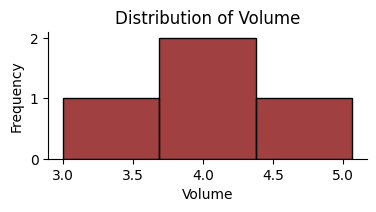

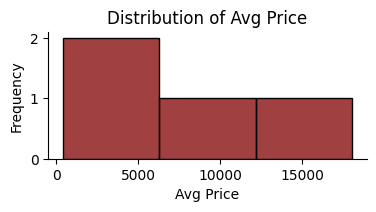

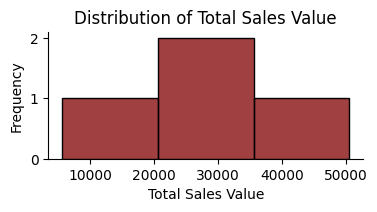

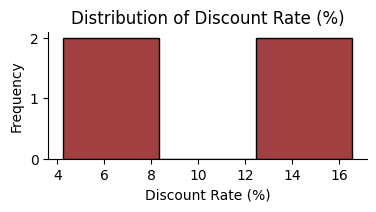

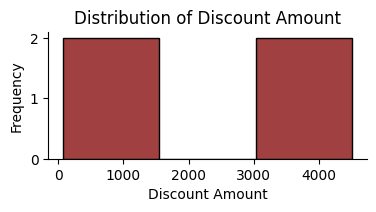

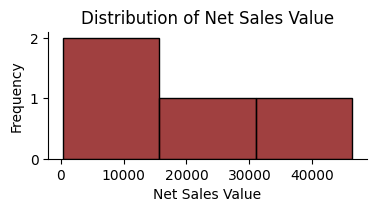

In [46]:
#Identify Numerical columns in the dataset.
numerical_columns = [
    "Volume",
    "Avg Price",
    "Total Sales Value",
    "Discount Rate (%)",
    "Discount Amount",
    "Net Sales Value"
]

# Plot histograms for each numerical column.
for column in numerical_columns:
    sns.displot(stats_df,x=stats_df[column],kind='hist',height=2,aspect=2,color='maroon')
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

In [40]:
sales_data[numerical_columns].skew()

Volume               2.731724
Avg Price            1.908873
Total Sales Value    1.534729
Discount Rate (%)   -1.062294
Discount Amount      1.913038
Net Sales Value      1.540822
dtype: float64

#### Analyze the distribution (e.g., skewness, presence of outliers) and provide inferences:

- Most numerical variables such as Volume, Avg Price, Total Sales Value, Discount Amount, and Net Sales Value are positively skewed, indicating that a few high-value transactions significantly influence overall sales.

- Discount Rate (%) is negatively skewed, suggesting higher discount percentages are more common.

- The strong positive skewness in Volume indicates possible high-value outliers.

#### ●	Box Plots:
	Create boxplots for numerical variables to identify outliers and the interquartile range.
	Discuss any findings, such as extreme values or unusual distributions.

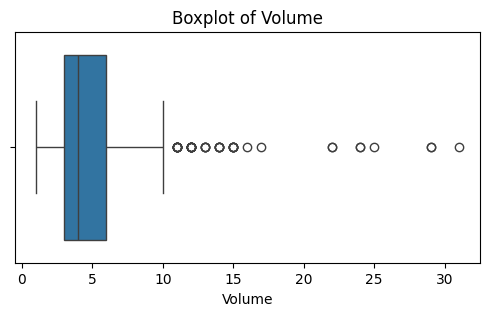

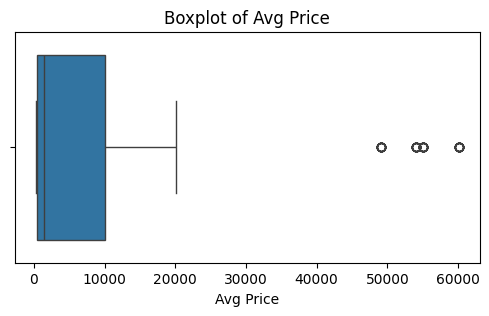

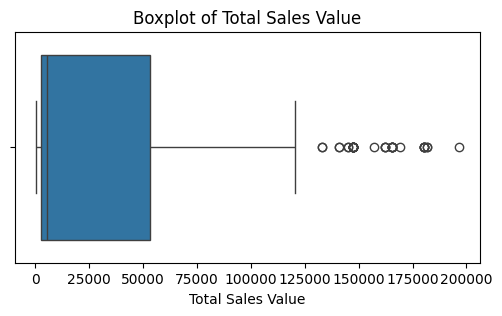

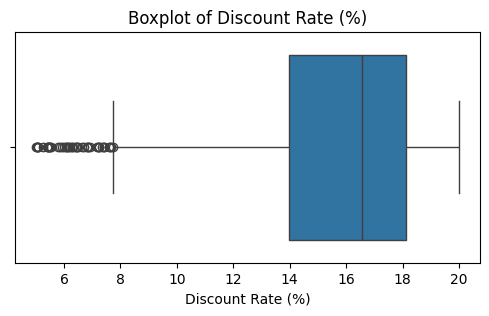

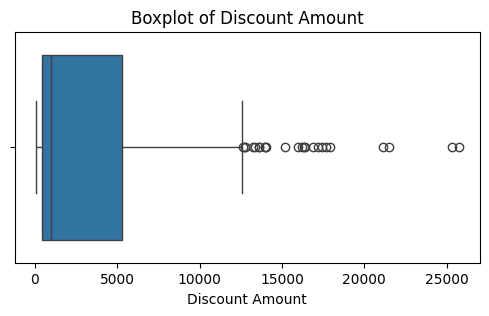

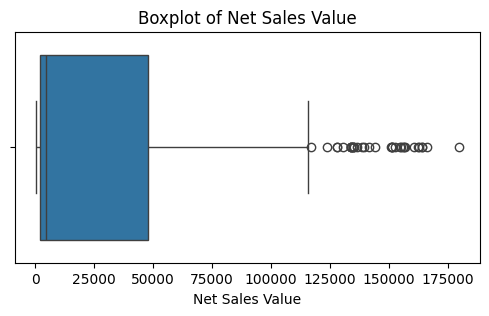

In [59]:
#Create boxplots for numerical variables to identify outliers and the interquartile range.
for column in numerical_columns:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=sales_data[column])
    plt.title(f"Boxplot of {column}")
    plt.show()

#### Discuss any findings, such as extreme values or unusual distributions

- Most numerical variables such as Volume, Avg Price, Total Sales Value, Discount Amount, and Net Sales Value are positively skewed, indicating that a few high-value transactions significantly influence overall sales.

- Discount Rate (%) is negatively skewed, suggesting higher discount percentages are more common.

- The strong positive skewness in Volume indicates possible high-value outliers.

#### ●	Bar Chart Analysis for Categorical Column:
	Identify categorical columns in the dataset.
	Create bar charts to visualize the frequency or count of each category.
	Analyze the distribution of categories and provide insights.

In [58]:
#identify categorical dataset
categorical_columns = sales_data.select_dtypes(include=['object']).columns
#display categorical dataset
categorical_columns

Index(['Date', 'Day', 'SKU', 'City', 'BU', 'Brand', 'Model'], dtype='object')

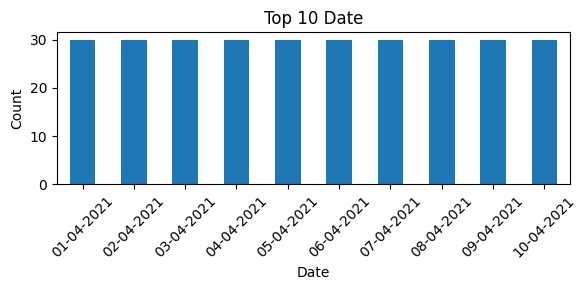

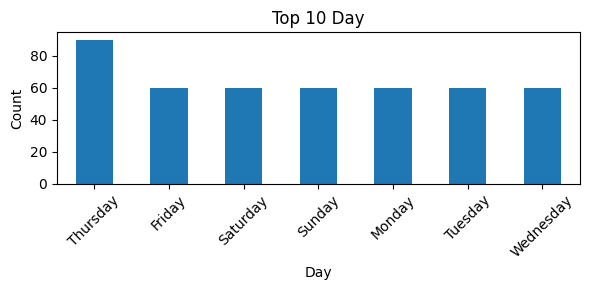

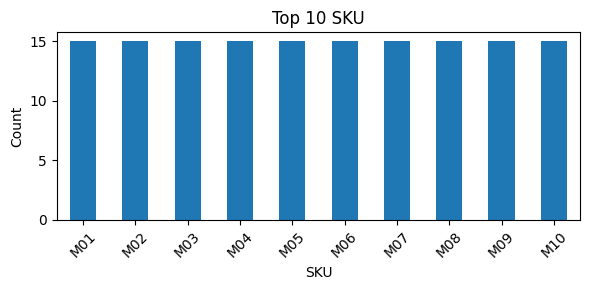

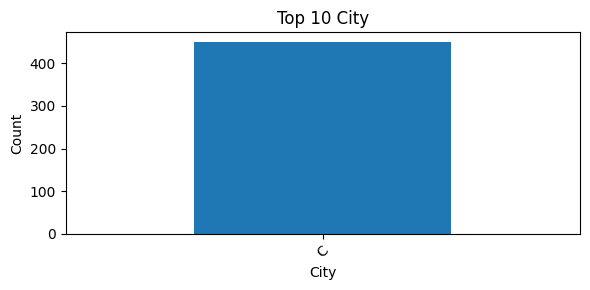

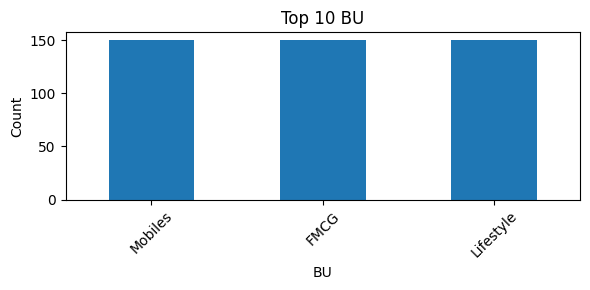

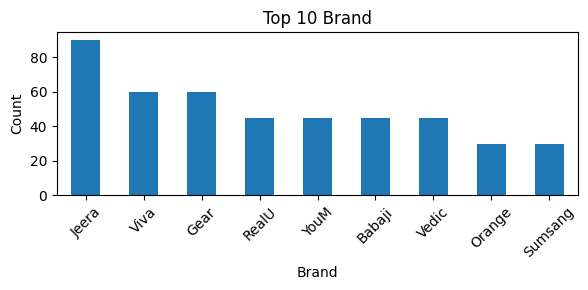

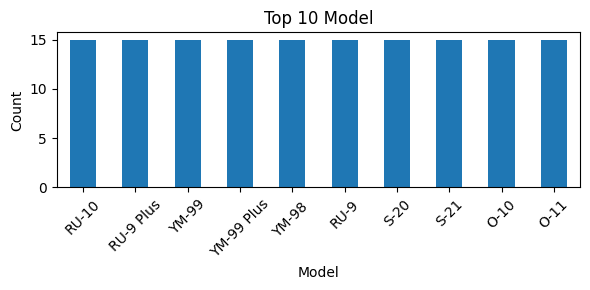

In [57]:
#Create bar charts to visualize the frequency or count of each category.
for column in categorical_columns:
    plt.figure(figsize=(6,3))
    
    top_values = sales_data[column].value_counts().nlargest(10)
    
    top_values.plot(kind='bar')
    
    plt.title(f"Top 10 {column}")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

#### Analyze the distribution of categories and provide insights

- The bar charts show that the three business units (Mobiles, FMCG, Lifestyle) have nearly equal representation in the dataset.

- Certain brands appear more frequently than others, indicating higher sales concentration in specific brands.

- All SKUs and models have almost equal counts, suggesting balanced product distribution.

- The City column contains only one category, meaning the dataset represents sales from a single city.

- The Day distribution is fairly uniform, with slightly higher frequency on Thursday.

- Overall, categorical data shows balanced distribution with minor dominance in specific brands and days.


## conclusion:

Sales data shows that most transactions are of smaller value, but a few large transactions significantly increase overall revenue. Some outliers are present in sales and pricing variables. Discount patterns appear structured, and category distribution is mostly balanced with slight dominance in certain brands.
